In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from  plotly.offline import iplot
import plotly as py 
import plotly.tools as tls 


In [4]:
df=pd.read_csv('ippl.csv')
df

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,129,Khaleel Ahmed,7,1,0,0,0*,0.00,2,0.00,0,0,0,0
129,130,Arshdeep Singh,8,1,0,0,0*,0.00,3,0.00,0,0,0,0
130,131,Daniel Sams,3,1,0,0,0*,0.00,2,0.00,0,0,0,0
131,132,Shreevats Goswami,2,2,0,0,0*,0.00,4,0.00,0,0,0,0


In [46]:
df.head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30


In [47]:
df.tail()


,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s
128,129,Khaleel Ahmed,7,1,0,0,0*,0.0,2,0.0,0,0,0,0
129,130,Arshdeep Singh,8,1,0,0,0*,0.0,3,0.0,0,0,0,0
130,131,Daniel Sams,3,1,0,0,0*,0.0,2,0.0,0,0,0,0
131,132,Shreevats Goswami,2,2,0,0,0*,0.0,4,0.0,0,0,0,0
132,133,Trent Boult,15,1,0,0,0*,0.0,1,0.0,0,0,0,0


In [ ]:
##1 What is the maximum number of matches played by an individual player in a season? Print the player name along with the number of matched played.

In [34]:
df.loc[df['Matches'].idxmax(),['Player','Matches']]

Player     Shikhar Dhawan
Matches                17
Name: 1, dtype: object

In [ ]:
##2 Top 2 players with maximum Average who have scored atleast 2 half centuries ?

In [49]:

df[df['50'].astype(int) >= 2].nlargest(2, 'Avg')[['Player', 'Avg']]


,Player,Avg
36,Wriddhiman Saha,71.33
4,Ishan Kishan,57.33


In [ ]:
##3 Create 2 new columns based on Player name. First column will have first name and second column will have last name. 
Eg: for the player Shikhar Dhawan, Shikhar will be the first name and Dhawan will be the last name.

In [56]:
df["First Name"] = df["Player"].apply(lambda x: x.split()[0])
df["Last Name"] = df["Player"].apply(lambda x: " ".join(x.split()[1:]) if len(x.split()) > 1 else "")
df[["Player", "First Name", "Last Name"]]


,Player,First Name,Last Name
0,KL Rahul,KL,Rahul
1,Shikhar Dhawan,Shikhar,Dhawan
2,David Warner,David,Warner
3,Shreyas Iyer,Shreyas,Iyer
4,Ishan Kishan,Ishan,Kishan
...,...,...,...
128,Khaleel Ahmed,Khaleel,Ahmed
129,Arshdeep Singh,Arshdeep,Singh
130,Daniel Sams,Daniel,Sams
131,Shreevats Goswami,Shreevats,Goswami


In [ ]:
##4 Create a new column (Cleaned_Highest_score) based on Highest score variable. Remove the Asterik(*) mark and convert the data type into INT.

In [57]:
df["Cleaned_Highest_Score"] = df["Highest Score"].astype(str).str.replace("*", "", regex=False).astype(int)
df[["Highest Score", "Cleaned_Highest_Score"]]


,Highest Score,Cleaned_Highest_Score
0,132*,132
1,106*,106
2,85*,85
3,88*,88
4,99,99
...,...,...
128,0*,0
129,0*,0
130,0*,0
131,0*,0


In [55]:
##5 Print the total number of centuries scored in the entire season.
total_centuries = df['100'].sum()
print(total_centuries)


5


In [ ]:
##6 Print all the player names whose strike rate is less than the average strike rate of all players in entire season. Print the player name,
his strike rate and average strike rate.

In [16]:
avg_strike_rate = df["Strike rate"].mean()
low_strike_rate_players = df[df["Strike rate"] < avg_strike_rate][["Player", "Strike rate"]]
low_strike_rate_players["Average Strike Rate"] = avg_strike_rate
low_strike_rate_players


,Player,Strike rate,Average Strike Rate
51,Ajinkya Rahane,105.60,107.364737
55,Glenn Maxwell,101.88,107.364737
58,Vijay Shankar,101.04,107.364737
61,Josh Philippe,101.29,107.364737
62,Gurkeerat Singh,88.75,107.364737
65,Kedar Jadhav,93.93,107.364737
70,Yashasvi Jaiswal,90.90,107.364737
71,Shreyas Gopal,94.87,107.364737
77,Murali Vijay,74.41,107.364737
79,Chris Jordan,93.54,107.364737


In [ ]:
##7 Please check the correlation between the features and create a heat map.

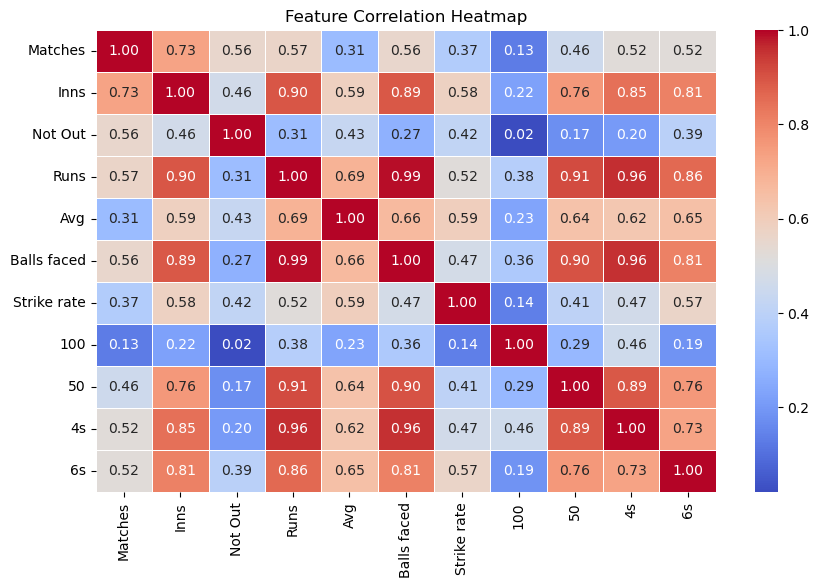

In [61]:

df.columns = df.columns.str.strip()

numeric_cols = ["Matches", "Inns", "Not Out", "Runs", "Avg", "Balls faced", "Strike rate", "100", "50", "4s", "6s"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()



In [ ]:
##8  . Check the list of players who has an average greater than 50 as well strike rate above 120. Print player name, average and strike rate.

In [73]:

filtered_players = df[(df['Avg'] > 50) & (df['Strike rate'] > 120)]
result = filtered_players[['Player', 'Avg', 'Strike rate']]
result


,Player,Avg,Strike rate
0,KL Rahul,55.83,129.34
4,Ishan Kishan,57.33,145.76
31,Kieron Pollard,53.60,191.42
36,Wriddhiman Saha,71.33,139.86
37,Ruturaj Gaikwad,51.00,120.71
57,Deepak Hooda,101.00,142.25
60,Tom Curran,83.00,133.87


In [ ]:
##9 . Please check the list of players who has an average greater than 40 and balls faced above 100. Print player name, average and balls faced.

In [ ]:

data = {
    'Player': ['Player A', 'Player B', 'Player C', 'Player D'],
    'Avg': [45.0, 38.5, 50.2, 41.3],
    'Balls faced': [120, 80, 150, 110]
}

df = pd.DataFrame(data)

In [72]:


# Filter players with Avg > 40 and Balls faced > 100
filtered_players = df[(df['Avg'] > 40) & (df['Balls faced'] > 100)]

# Display the relevant columns
result = filtered_players[['Player', 'Avg', 'Balls faced']]
result


,Player,Avg,Balls faced
0,KL Rahul,55.83,518
1,Shikhar Dhawan,44.14,427
4,Ishan Kishan,57.33,354
8,Virat Kohli,42.36,384
9,ABD Villiers,45.40,286
10,Faf Duplessis,40.81,319
14,Eoin Morgan,41.80,302
24,Kane Williamson,45.28,237
27,Chris Gayle,41.14,210
28,Ben Stokes,40.71,200


In [ ]:
##10 Players who scored atleast one century in this season. Create visualization

In [29]:
century_scorers = df[df['100s'] >= 1]


C:\Users\TRUST\AppData\Local\Temp\ipykernel_29356\1282727117.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




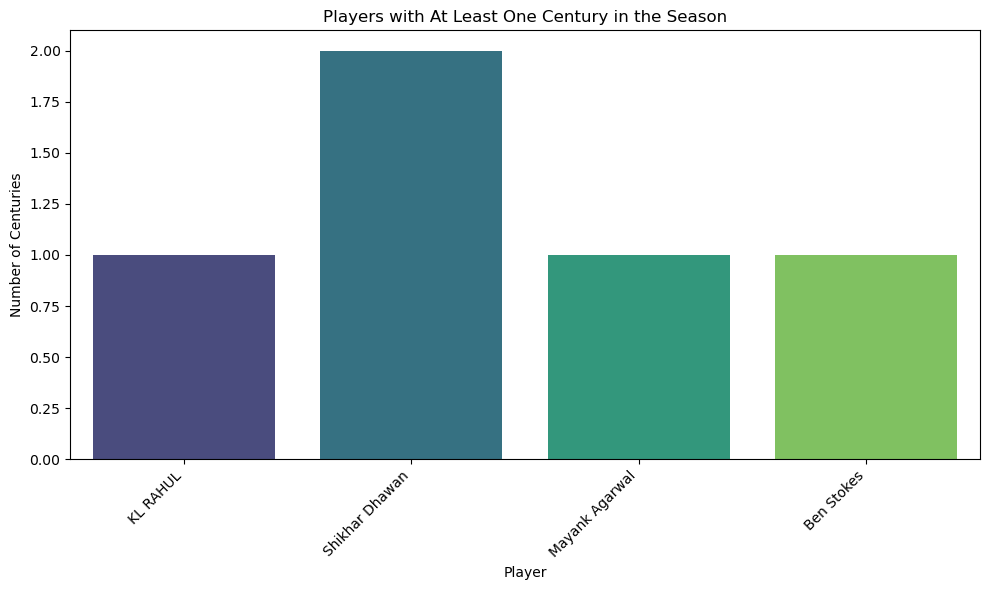

In [35]:


data = {
    'Player': ['KL RAHUL', 'Shikhar Dhawan', 'Mayank Agarwal', 'Ben Stokes'],
    '100s': [1, 2, 1, 1]
}

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Player', y='100s', data=data, palette='viridis')

# Set axis labels and title
ax.set_xlabel('Player')
ax.set_ylabel('Number of Centuries')
ax.set_title('Players with At Least One Century in the Season')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
##11 Players who scored atleast 4 half centuries in this season.

In [71]:

 four_or_more_50s = df[df['50'] >= 4]

result = four_or_more_50s[['Player', '50', 'Runs']]
result


,Player,50,Runs
0,KL Rahul,5,670
1,Shikhar Dhawan,4,618
2,David Warner,4,548
4,Ishan Kishan,4,516
5,Quinton Kock,4,503
6,Suryakumar Yadav,4,480
7,Devdutt Padikkal,5,473
9,ABD Villiers,5,454
10,Faf Duplessis,4,449


In [ ]:
##12 . Check the list of players who hit more than 45 boundaries and more than 10 sixes in this season.

In [70]:


df.columns = df.columns.str.strip()

# Convert '4s' and '6s' to numeric to avoid errors
df["4s"] = pd.to_numeric(df["4s"], errors="coerce")
df["6s"] = pd.to_numeric(df["6s"], errors="coerce")

# Filter players who hit more than 45 fours and more than 10 sixes
filtered_players = df[(df["4s"] > 45) & (df["6s"] > 10)][["Player", "4s", "6s"]]

# Display results
print("Players who hit more than 45 fours and more than 10 sixes:")
filtered_players


Players who hit more than 45 fours and more than 10 sixes:


,Player,4s,6s
0,KL Rahul,58,23
1,Shikhar Dhawan,67,12
2,David Warner,52,14
5,Quinton Kock,46,22
6,Suryakumar Yadav,61,11


In [ ]:
##13 . Plot a histogram of number of matches played in a season by players.

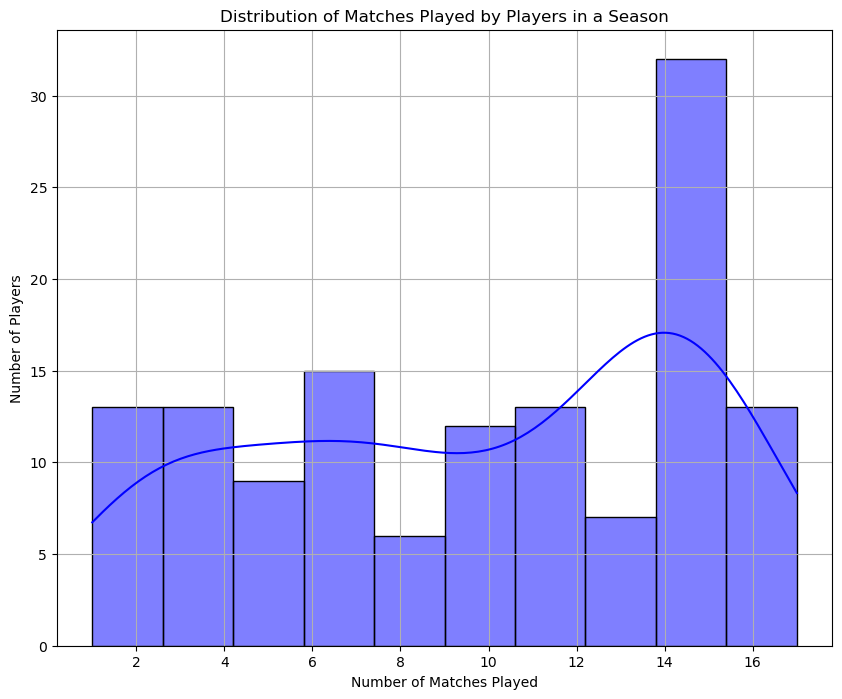

In [5]:

df.columns = df.columns.str.strip()
df["Matches"] = pd.to_numeric(df["Matches"], errors="coerce")

plt.figure(figsize=(10, 8))
sns.histplot(df["Matches"], bins=10, kde=True, color="blue")

plt.xlabel("Number of Matches Played")
plt.ylabel("Number of Players")
plt.title("Distribution of Matches Played by Players in a Season")
plt.grid(True)

plt.show()


In [ ]:
##14 Plot the histogram of balls faced by players.

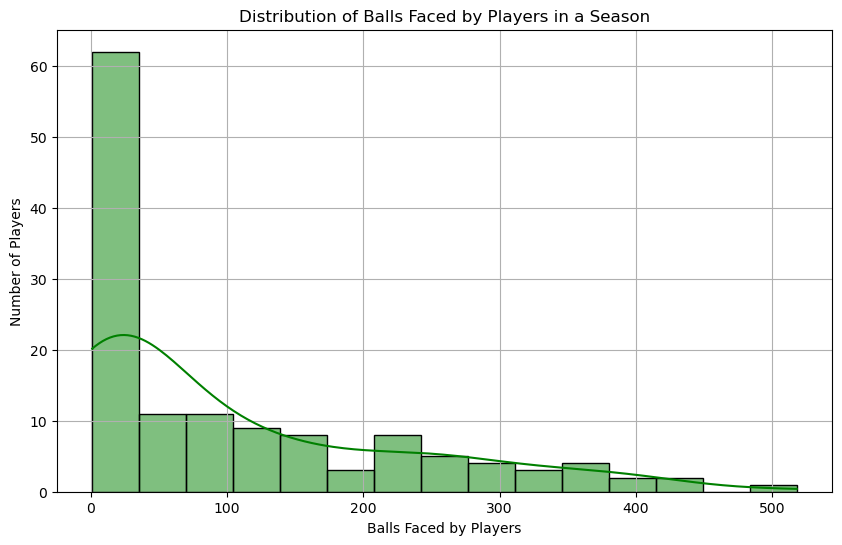

In [67]:

df.columns = df.columns.str.strip()

df["Balls faced"] = pd.to_numeric(df["Balls faced"], errors="coerce")

plt.figure(figsize=(10, 6))
sns.histplot(df["Balls faced"], bins=15, kde=True, color="green")
plt.xlabel("Balls Faced by Players")
plt.ylabel("Number of Players")
plt.title("Distribution of Balls Faced by Players in a Season")
plt.grid(True)
plt.show()


In [ ]:
##15 Top 10 players with most runs in a season.

In [69]:

df.columns = df.columns.str.strip()
df["Runs"] = pd.to_numeric(df["Runs"], errors="coerce")
top_scorers = df.nlargest(10, "Runs")[["Player", "Runs"]]

print("Top 10 Players with Most Runs in a Season:")
top_scorers


Top 10 Players with Most Runs in a Season:


,Player,Runs
0,KL Rahul,670
1,Shikhar Dhawan,618
2,David Warner,548
3,Shreyas Iyer,519
4,Ishan Kishan,516
5,Quinton Kock,503
6,Suryakumar Yadav,480
7,Devdutt Padikkal,473
8,Virat Kohli,466
9,ABD Villiers,454


In [ ]:
##16 Print the players who played the match but didn't get the batting.

In [75]:

df.columns = df.columns.str.strip()

df["Matches"] = pd.to_numeric(df["Matches"], errors="coerce")
df["Inns"] = pd.to_numeric(df["Inns"], errors="coerce")
players_did_not_bat = df[(df["Matches"] > 0) & (df["Inns"] == 0)][["Player", "Matches"]]
print("Players who played but didn't get to bat:")
print(players_did_not_bat)


Players who played but didn't get to bat:
Empty DataFrame
Columns: [Player, Matches]
Index: []


In [ ]:
##17 Create a new column to show the percentage of total runs scored in 4s and 6s. Then print the top 5 players with maximum percentage.

In [77]:

df.columns = df.columns.str.strip()
df["Runs"] = pd.to_numeric(df["Runs"], errors="coerce")
df["4s"] = pd.to_numeric(df["4s"], errors="coerce")
df["6s"] = pd.to_numeric(df["6s"], errors="coerce")

df["Boundary %"] = ((df["4s"] * 4 + df["6s"] * 6) / df["Runs"]) * 100

df["Boundary %"] = df["Boundary %"].fillna(0)

top_boundary_players = df.nlargest(5, "Boundary %")[["Player", "Runs", "4s", "6s", "Boundary %"]]

print("Top 5 players with highest percentage of runs from boundaries:")
top_boundary_players


Top 5 players with highest percentage of runs from boundaries:


,Player,Runs,4s,6s,Boundary %
109,Andrew Tye,6,0,1,100.000000
48,Andre Russell,117,9,9,76.923077
74,Chris Morris,34,2,3,76.470588
29,Hardik Pandya,281,14,25,73.309609
47,Sunil Narine,121,10,8,72.727273


In [ ]:
##18 . Print the players with top 5 Not out percentages (Not Out percentage can be calculated as number of Not outs divided by Innings).

In [79]:

df.columns = df.columns.str.strip()
df["Not Out"] = pd.to_numeric(df["Not Out"], errors="coerce")
df["Inns"] = pd.to_numeric(df["Inns"], errors="coerce")

df["Not Out %"] = (df["Not Out"] / df["Inns"]) * 100
df["Not Out %"] = df["Not Out %"].fillna(0)
top_not_out_players = df.nlargest(5, "Not Out %")[["Player", "Inns", "Not Out", "Not Out %"]]
print("Top 5 players with highest Not Out percentage:")
top_not_out_players


Top 5 players with highest Not Out percentage:


,Player,Inns,Not Out,Not Out %
62,Gurkeerat Singh,5,5,100.0
68,Lockie Ferguson,2,2,100.0
93,Imran Tahir,1,1,100.0
97,Mohammad Nabi,1,1,100.0
105,Pravin Dubey,1,1,100.0


In [ ]:
##19 Create visualization of top 10 players with highest number of sixes.

C:\Users\TRUST\AppData\Local\Temp\ipykernel_14252\976867859.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




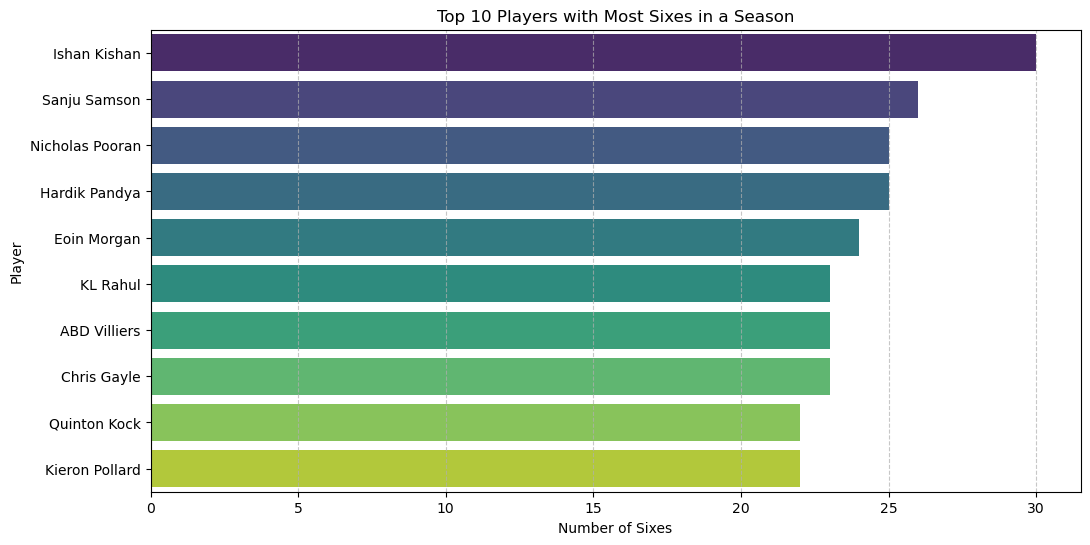

In [80]:

df.columns = df.columns.str.strip()
df["6s"] = pd.to_numeric(df["6s"], errors="coerce")
top_six_hitters = df.nlargest(10, "6s")[["Player", "6s"]]

plt.figure(figsize=(12, 6))
sns.barplot(x="6s", y="Player", data=top_six_hitters, palette="viridis")
plt.xlabel("Number of Sixes")
plt.ylabel("Player")
plt.title("Top 10 Players with Most Sixes in a Season")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()


In [ ]:
##20 Scatter plot of runs scored by a player v/s balls faced in a season. Then find the relationship between these 2 variables.

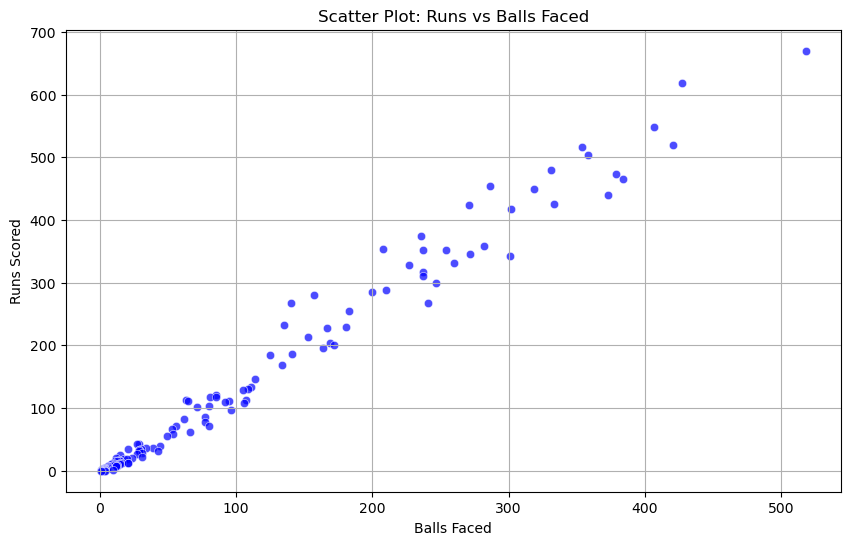

Correlation between Runs and Balls Faced: 0.99


In [81]:

df.columns = df.columns.str.strip()
df["Runs"] = pd.to_numeric(df["Runs"], errors="coerce")
df["Balls faced"] = pd.to_numeric(df["Balls faced"], errors="coerce")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["Balls faced"], y=df["Runs"], color="blue", alpha=0.7)

plt.xlabel("Balls Faced")
plt.ylabel("Runs Scored")
plt.title("Scatter Plot: Runs vs Balls Faced")
plt.grid(True)

plt.show()

correlation = df["Balls faced"].corr(df["Runs"])
print(f"Correlation between Runs and Balls Faced: {correlation:.2f}")
